This dataset asks whether moments in Rhode’s brand timeline (product launches, viral beauty trends, and major business events) correspond with spikes in Google search interest. In other words, does public search attention rise when Rhode creates or receives a cultural/product moment?

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
trends = pd.read_csv("rhodebeauty.csv", skiprows=1, header=None)

trends.head()

,0,1,2,3,4,5
0,2021-05-01,2,0,1,0,0
1,2021-06-01,2,0,1,0,0
2,2021-07-01,2,0,0,0,0
3,2021-08-01,2,0,1,0,0
4,2021-09-01,1,0,0,0,0


In [9]:
trends.columns = [
    "date",
    "rhode_skin",
    "rhode_lip_treatment",
    "rhode_phone_case",
    "glazed_donut_skin",
    "hailey_bieber_skincare"
]

trends["date"] = pd.to_datetime(trends["date"])

trends.head()

,date,rhode_skin,rhode_lip_treatment,rhode_phone_case,glazed_donut_skin,hailey_bieber_skincare
0,2021-05-01,2,0,1,0,0
1,2021-06-01,2,0,1,0,0
2,2021-07-01,2,0,0,0,0
3,2021-08-01,2,0,1,0,0
4,2021-09-01,1,0,0,0,0


In [10]:
trends_long = trends.melt(
    id_vars="date",
    var_name="search_term",
    value_name="google_trends_interest"
)

trends_long.head()

,date,search_term,google_trends_interest
0,2021-05-01,rhode_skin,2
1,2021-06-01,rhode_skin,2
2,2021-07-01,rhode_skin,2
3,2021-08-01,rhode_skin,2
4,2021-09-01,rhode_skin,1


In [11]:
trends_long["search_term"].value_counts()

search_term
rhode_skin                61
rhode_lip_treatment       61
rhode_phone_case          61
glazed_donut_skin         61
hailey_bieber_skincare    61
Name: count, dtype: int64

In [12]:
trends_long.sort_values(["date", "search_term"]).head(20)

,date,search_term,google_trends_interest
183,2021-05-01,glazed_donut_skin,0
244,2021-05-01,hailey_bieber_skincare,0
61,2021-05-01,rhode_lip_treatment,0
122,2021-05-01,rhode_phone_case,1
0,2021-05-01,rhode_skin,2
184,2021-06-01,glazed_donut_skin,0
245,2021-06-01,hailey_bieber_skincare,0
62,2021-06-01,rhode_lip_treatment,0
123,2021-06-01,rhode_phone_case,1
1,2021-06-01,rhode_skin,2


In [13]:
trends_long["month"] = trends_long["date"].dt.to_period("M").dt.start_time

trends_long.head()

,date,search_term,google_trends_interest,month
0,2021-05-01,rhode_skin,2,2021-05-01
1,2021-06-01,rhode_skin,2,2021-06-01
2,2021-07-01,rhode_skin,2,2021-07-01
3,2021-08-01,rhode_skin,2,2021-08-01
4,2021-09-01,rhode_skin,1,2021-09-01


In [14]:
events = pd.DataFrame({
    "date": pd.to_datetime([
        "2022-01-27",
        "2022-06-15",
        "2022-06-15",
        "2023-03-22",
        "2023-08-28",
        "2023-09-28",
        "2024-01-25",
        "2024-02-27",
        "2024-06-20",
        "2024-10-28",
        "2025-01-30",
        "2025-05-28",
        "2025-09-04"
    ]),
    "event_name": [
        "Glazed donut skin identified as major Hailey Bieber beauty trend",
        "Rhode officially launches",
        "Peptide Lip Treatment included in first Rhode drop",
        "Rhode reports major waitlist and expansion momentum",
        "Strawberry Glaze Peptide Lip Treatment launches with Krispy Kreme",
        "Rhode Peptide Lip Tint launches",
        "Pineapple Refresh Cleanser becomes available",
        "Rhode Lip Case launches",
        "Rhode Pocket Blush launches",
        "Rhode Barrier Butter launches",
        "Peptide Lip Shape launches",
        "e.l.f. Beauty announces Rhode acquisition",
        "Rhode launches at Sephora U.S. and Canada"
    ],
    "event_type": [
        "viral_beauty_trend",
        "brand_launch",
        "product_launch",
        "business_growth",
        "product_collab",
        "product_launch",
        "skincare_product_launch",
        "viral_product_launch",
        "color_cosmetics_launch",
        "skincare_product_launch",
        "lip_product_launch",
        "business_event",
        "retail_expansion"
    ],
    "related_search_term": [
        "glazed_donut_skin",
        "rhode_skin",
        "rhode_lip_treatment",
        "rhode_skin",
        "rhode_lip_treatment",
        "rhode_lip_treatment",
        "rhode_skin",
        "rhode_phone_case",
        "hailey_bieber_skincare",
        "rhode_skin",
        "rhode_lip_treatment",
        "rhode_skin",
        "hailey_bieber_skincare"
    ]
})

events

,date,event_name,event_type,related_search_term
0,2022-01-27,Glazed donut skin identified as major Hailey B...,viral_beauty_trend,glazed_donut_skin
1,2022-06-15,Rhode officially launches,brand_launch,rhode_skin
2,2022-06-15,Peptide Lip Treatment included in first Rhode ...,product_launch,rhode_lip_treatment
3,2023-03-22,Rhode reports major waitlist and expansion mom...,business_growth,rhode_skin
4,2023-08-28,Strawberry Glaze Peptide Lip Treatment launche...,product_collab,rhode_lip_treatment
5,2023-09-28,Rhode Peptide Lip Tint launches,product_launch,rhode_lip_treatment
6,2024-01-25,Pineapple Refresh Cleanser becomes available,skincare_product_launch,rhode_skin
7,2024-02-27,Rhode Lip Case launches,viral_product_launch,rhode_phone_case
8,2024-06-20,Rhode Pocket Blush launches,color_cosmetics_launch,hailey_bieber_skincare
9,2024-10-28,Rhode Barrier Butter launches,skincare_product_launch,rhode_skin


In [15]:
events["month"] = events["date"].dt.to_period("M").dt.start_time

events

,date,event_name,event_type,related_search_term,month
0,2022-01-27,Glazed donut skin identified as major Hailey B...,viral_beauty_trend,glazed_donut_skin,2022-01-01
1,2022-06-15,Rhode officially launches,brand_launch,rhode_skin,2022-06-01
2,2022-06-15,Peptide Lip Treatment included in first Rhode ...,product_launch,rhode_lip_treatment,2022-06-01
3,2023-03-22,Rhode reports major waitlist and expansion mom...,business_growth,rhode_skin,2023-03-01
4,2023-08-28,Strawberry Glaze Peptide Lip Treatment launche...,product_collab,rhode_lip_treatment,2023-08-01
5,2023-09-28,Rhode Peptide Lip Tint launches,product_launch,rhode_lip_treatment,2023-09-01
6,2024-01-25,Pineapple Refresh Cleanser becomes available,skincare_product_launch,rhode_skin,2024-01-01
7,2024-02-27,Rhode Lip Case launches,viral_product_launch,rhode_phone_case,2024-02-01
8,2024-06-20,Rhode Pocket Blush launches,color_cosmetics_launch,hailey_bieber_skincare,2024-06-01
9,2024-10-28,Rhode Barrier Butter launches,skincare_product_launch,rhode_skin,2024-10-01


In [16]:
merged = trends_long.merge(
    events,
    left_on=["month", "search_term"],
    right_on=["month", "related_search_term"],
    how="left",
    suffixes=("_trend", "_event")
)

merged.head()

,date_trend,search_term,google_trends_interest,month,date_event,event_name,event_type,related_search_term
0,2021-05-01,rhode_skin,2,2021-05-01,NaT,NaN,NaN,NaN
1,2021-06-01,rhode_skin,2,2021-06-01,NaT,NaN,NaN,NaN
2,2021-07-01,rhode_skin,2,2021-07-01,NaT,NaN,NaN,NaN
3,2021-08-01,rhode_skin,2,2021-08-01,NaT,NaN,NaN,NaN
4,2021-09-01,rhode_skin,1,2021-09-01,NaT,NaN,NaN,NaN


In [17]:
merged["event_name"] = merged["event_name"].fillna("none")
merged["event_type"] = merged["event_type"].fillna("none")
merged["related_search_term"] = merged["related_search_term"].fillna("none")

merged["is_event_month"] = merged["event_type"].apply(
    lambda x: 0 if x == "none" else 1
)

merged.head()

,date_trend,search_term,google_trends_interest,month,date_event,event_name,event_type,related_search_term,is_event_month
0,2021-05-01,rhode_skin,2,2021-05-01,NaT,none,none,none,0
1,2021-06-01,rhode_skin,2,2021-06-01,NaT,none,none,none,0
2,2021-07-01,rhode_skin,2,2021-07-01,NaT,none,none,none,0
3,2021-08-01,rhode_skin,2,2021-08-01,NaT,none,none,none,0
4,2021-09-01,rhode_skin,1,2021-09-01,NaT,none,none,none,0


In [18]:
final_dataset = merged[[
    "month",
    "search_term",
    "google_trends_interest",
    "event_name",
    "event_type",
    "is_event_month"
]].copy()

final_dataset.head()

,month,search_term,google_trends_interest,event_name,event_type,is_event_month
0,2021-05-01,rhode_skin,2,none,none,0
1,2021-06-01,rhode_skin,2,none,none,0
2,2021-07-01,rhode_skin,2,none,none,0
3,2021-08-01,rhode_skin,2,none,none,0
4,2021-09-01,rhode_skin,1,none,none,0


In [19]:
final_dataset.to_csv("rhode_google_trends_event_dataset.csv", index=False)

In [20]:
event_only_dataset = final_dataset[
    final_dataset["is_event_month"] == 1
].sort_values(["month", "search_term"])

event_only_dataset

,month,search_term,google_trends_interest,event_name,event_type,is_event_month
191,2022-01-01,glazed_donut_skin,0,Glazed donut skin identified as major Hailey B...,viral_beauty_trend,1
74,2022-06-01,rhode_lip_treatment,3,Peptide Lip Treatment included in first Rhode ...,product_launch,1
13,2022-06-01,rhode_skin,35,Rhode officially launches,brand_launch,1
22,2023-03-01,rhode_skin,13,Rhode reports major waitlist and expansion mom...,business_growth,1
88,2023-08-01,rhode_lip_treatment,9,Strawberry Glaze Peptide Lip Treatment launche...,product_collab,1
89,2023-09-01,rhode_lip_treatment,14,Rhode Peptide Lip Tint launches,product_launch,1
32,2024-01-01,rhode_skin,22,Pineapple Refresh Cleanser becomes available,skincare_product_launch,1
155,2024-02-01,rhode_phone_case,3,Rhode Lip Case launches,viral_product_launch,1
281,2024-06-01,hailey_bieber_skincare,0,Rhode Pocket Blush launches,color_cosmetics_launch,1
41,2024-10-01,rhode_skin,21,Rhode Barrier Butter launches,skincare_product_launch,1


In [21]:
event_only_dataset.to_csv("rhode_event_only_dataset.csv", index=False)

This dataset combines two forms of temporal data: Google Trends search interest and a manually coded timeline of Rhode-related events. The Google Trends data measures public search attention over time, while the event timeline identifies moments when Rhode entered beauty, fashion, or business discourse through product launches, viral trends, and major brand announcements.

Each row in the final dataset represents one search term in one month. By coding whether each month was an event month or a non-event month, the dataset allows me to compare search behavior during months when Rhode had a major cultural or product moment against months with no major event.

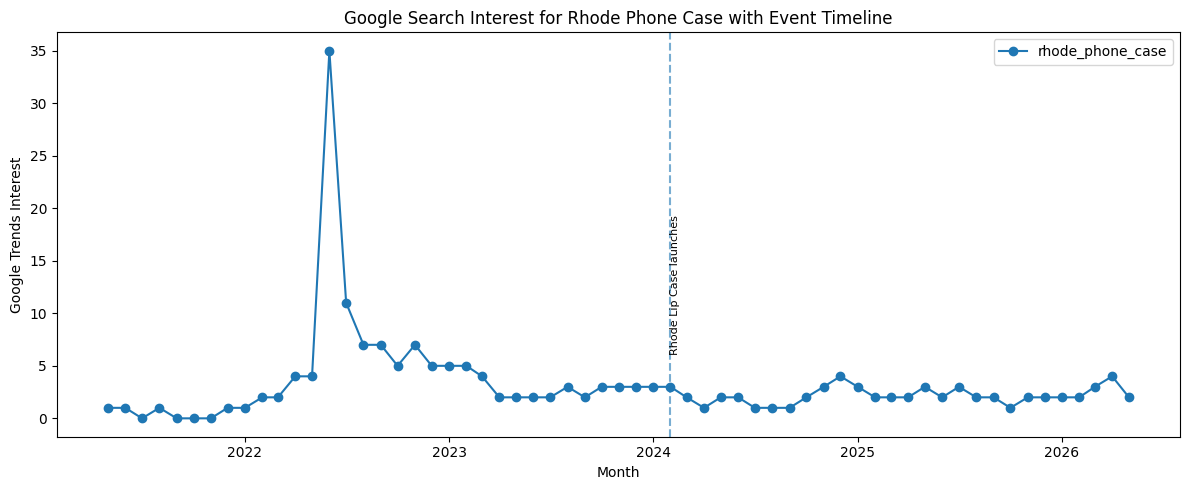

In [22]:
term = "rhode_phone_case"

subset = final_dataset[final_dataset["search_term"] == term].copy()
event_months = subset[subset["is_event_month"] == 1]

plt.figure(figsize=(12, 5))

plt.plot(
    subset["month"],
    subset["google_trends_interest"],
    marker="o",
    label=term
)

for _, row in event_months.iterrows():
    plt.axvline(row["month"], linestyle="--", alpha=0.6)
    plt.text(
        row["month"],
        row["google_trends_interest"] + 3,
        row["event_name"],
        rotation=90,
        fontsize=8,
        verticalalignment="bottom"
    )

plt.title("Google Search Interest for Rhode Phone Case with Event Timeline")
plt.xlabel("Month")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.tight_layout()
plt.show()

This graph shows that the official Rhode Lip Case launch does not correspond to the largest search spike for “rhode phone case.” Instead, the biggest spike happens much earlier, suggesting that search interest may have been shaped by anticipation, social media discussion, or unrelated uses of the phrase before the official launch. This complicates the event-based hypothesis: product launches matter, but search behavior does not always follow the exact timing of official brand events.

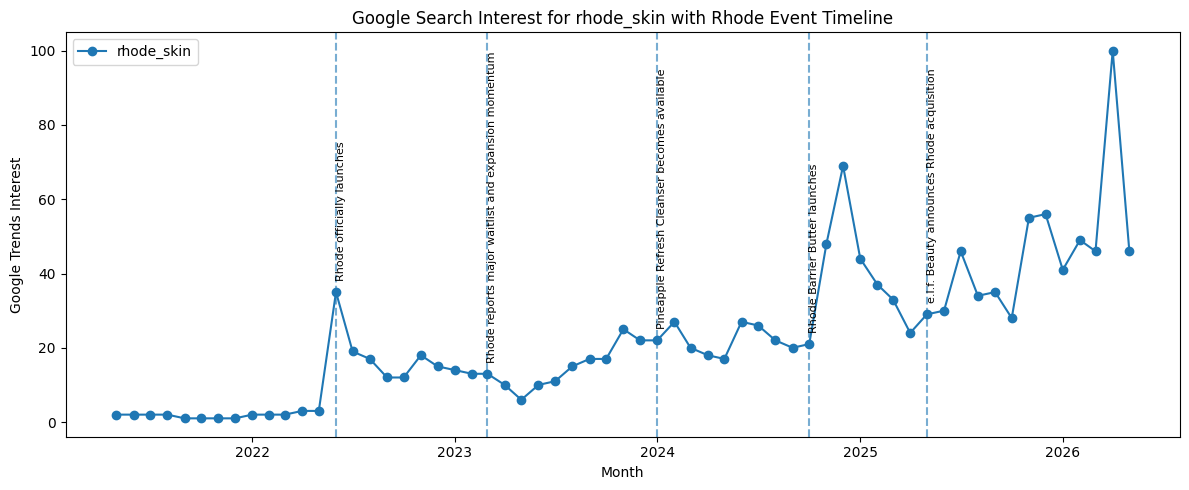

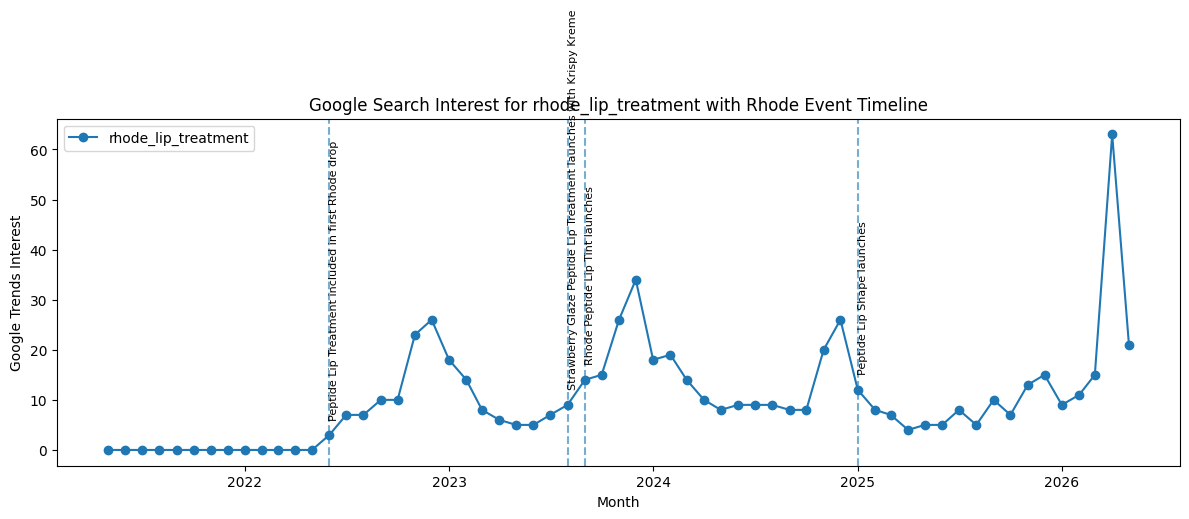

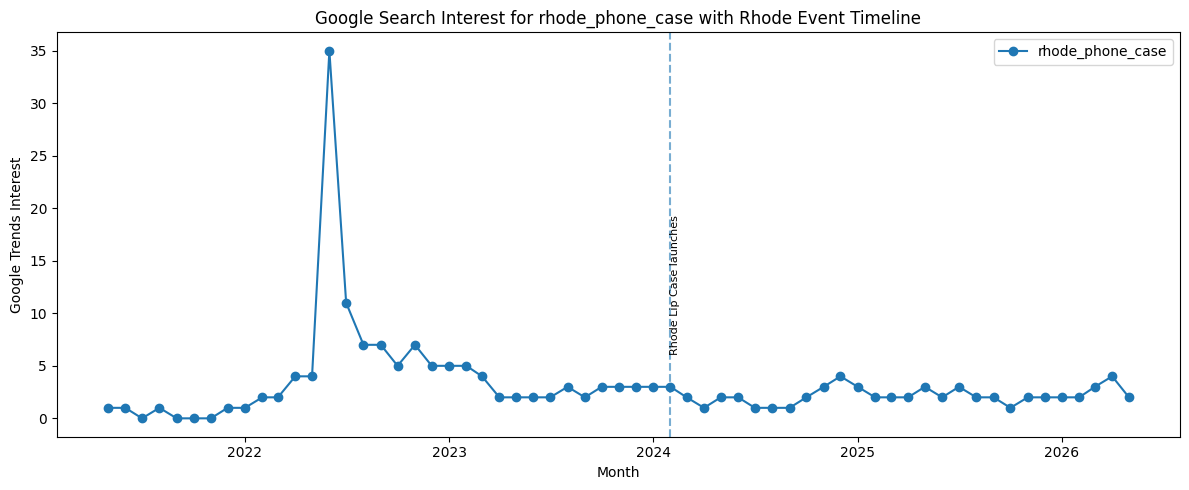

/tmp/ipykernel_1383341/966832668.py:29: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


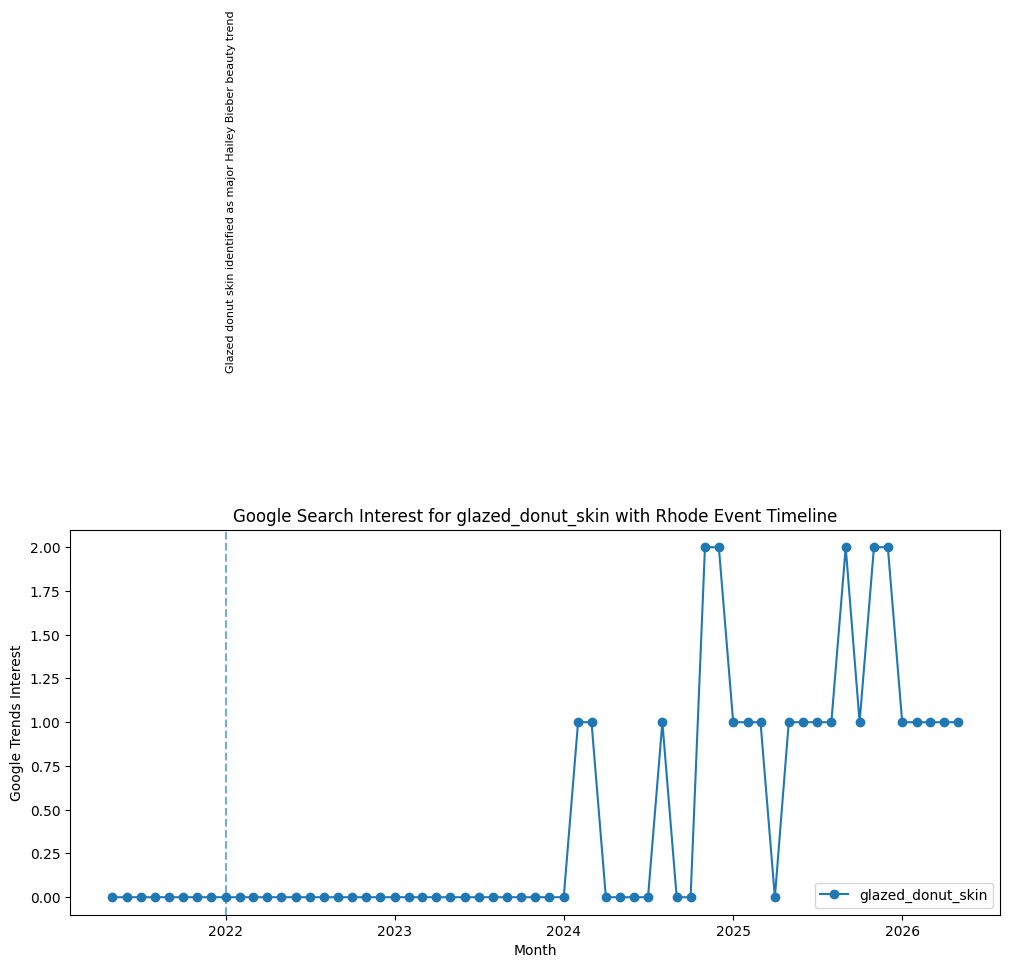

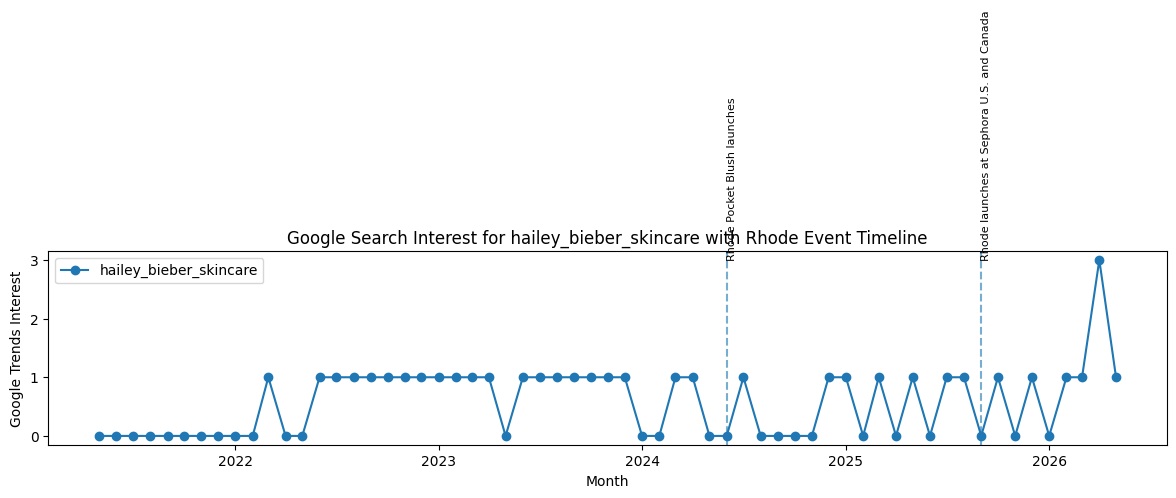

In [23]:
for term in final_dataset["search_term"].unique():
    subset = final_dataset[final_dataset["search_term"] == term].copy()
    event_months = subset[subset["is_event_month"] == 1]

    plt.figure(figsize=(12, 5))

    plt.plot(
        subset["month"],
        subset["google_trends_interest"],
        marker="o",
        label=term
    )

    for _, row in event_months.iterrows():
        plt.axvline(row["month"], linestyle="--", alpha=0.6)
        plt.text(
            row["month"],
            row["google_trends_interest"] + 3,
            row["event_name"],
            rotation=90,
            fontsize=8,
            verticalalignment="bottom"
        )

    plt.title(f"Google Search Interest for {term} with Rhode Event Timeline")
    plt.xlabel("Month")
    plt.ylabel("Google Trends Interest")
    plt.legend()
    plt.tight_layout()
    plt.show()

These timeline charts show that Rhode-related search interest does not rise evenly over time. Instead, attention appears clustered around specific moments: brand launches, product drops, viral beauty phrases, and business events. This supports the idea that Rhode’s visibility is event-driven. Public search interest seems to respond not only to the existence of the brand, but to moments when Rhode becomes newly relevant through products, scarcity, celebrity branding, or media coverage.

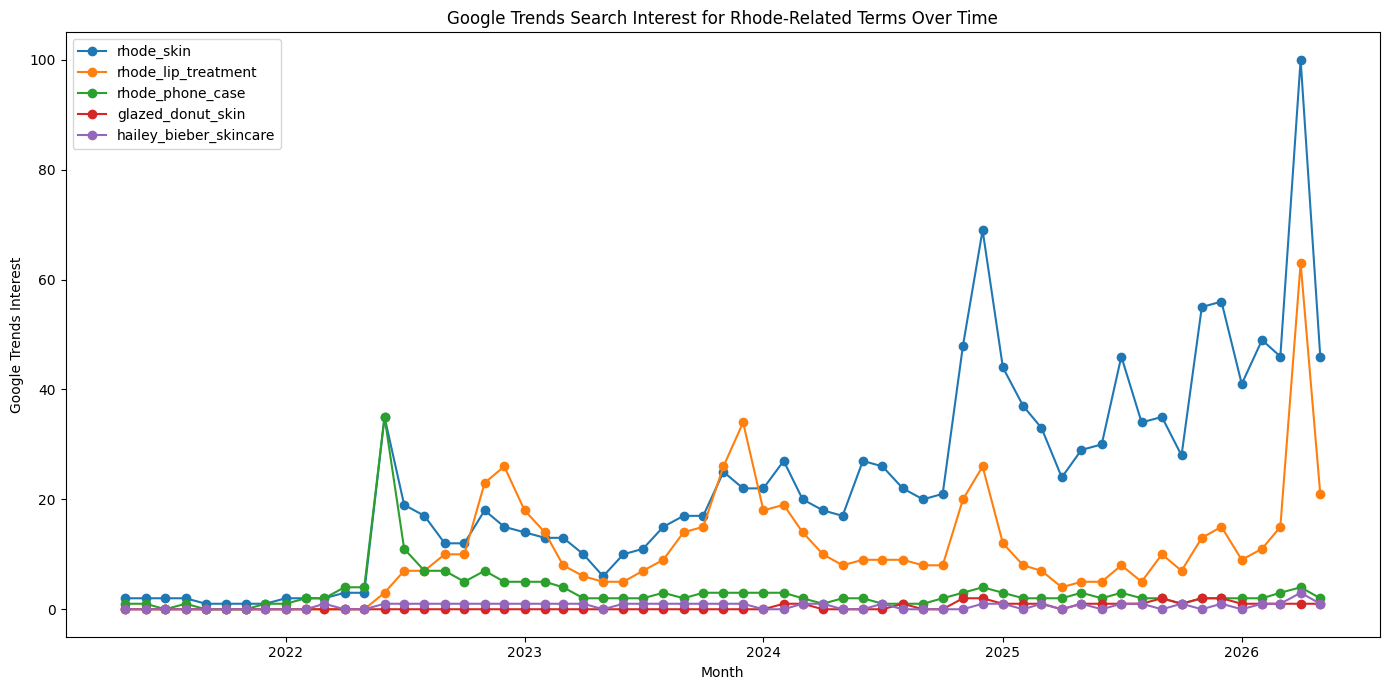

In [24]:
plt.figure(figsize=(14, 7))

for term in final_dataset["search_term"].unique():
    subset = final_dataset[final_dataset["search_term"] == term]
    plt.plot(
        subset["month"],
        subset["google_trends_interest"],
        marker="o",
        label=term
    )

plt.title("Google Trends Search Interest for Rhode-Related Terms Over Time")
plt.xlabel("Month")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.tight_layout()
plt.show()

This graph compares different kinds of Rhode-related attention. “Rhode skin” captures brand-level interest, while “rhode lip treatment” and “rhode phone case” capture product-specific interest. “Glazed donut skin” reflects a broader beauty aesthetic associated with Hailey Bieber, and “Hailey Bieber skincare” connects the brand to celebrity-driven search behavior. Comparing these terms helps show whether public interest is centered on the brand, the products, or the celebrity/aesthetic surrounding them.

In [25]:
event_comparison = final_dataset.groupby(
    ["search_term", "is_event_month"]
)["google_trends_interest"].mean().reset_index()

event_comparison

,search_term,is_event_month,google_trends_interest
0,glazed_donut_skin,0,0.433333
1,glazed_donut_skin,1,0.000000
2,hailey_bieber_skincare,0,0.610169
3,hailey_bieber_skincare,1,0.000000
4,rhode_lip_treatment,0,10.263158
5,rhode_lip_treatment,1,9.500000
6,rhode_phone_case,0,3.183333
7,rhode_phone_case,1,3.000000
8,rhode_skin,0,22.767857
9,rhode_skin,1,24.000000


In [26]:
event_comparison_pivot = event_comparison.pivot(
    index="search_term",
    columns="is_event_month",
    values="google_trends_interest"
)

event_comparison_pivot = event_comparison_pivot.rename(columns={
    0: "avg_non_event_month_interest",
    1: "avg_event_month_interest"
})

event_comparison_pivot

is_event_month,avg_non_event_month_interest,avg_event_month_interest
search_term,,
glazed_donut_skin,0.433333,0.0
hailey_bieber_skincare,0.610169,0.0
rhode_lip_treatment,10.263158,9.5
rhode_phone_case,3.183333,3.0
rhode_skin,22.767857,24.0


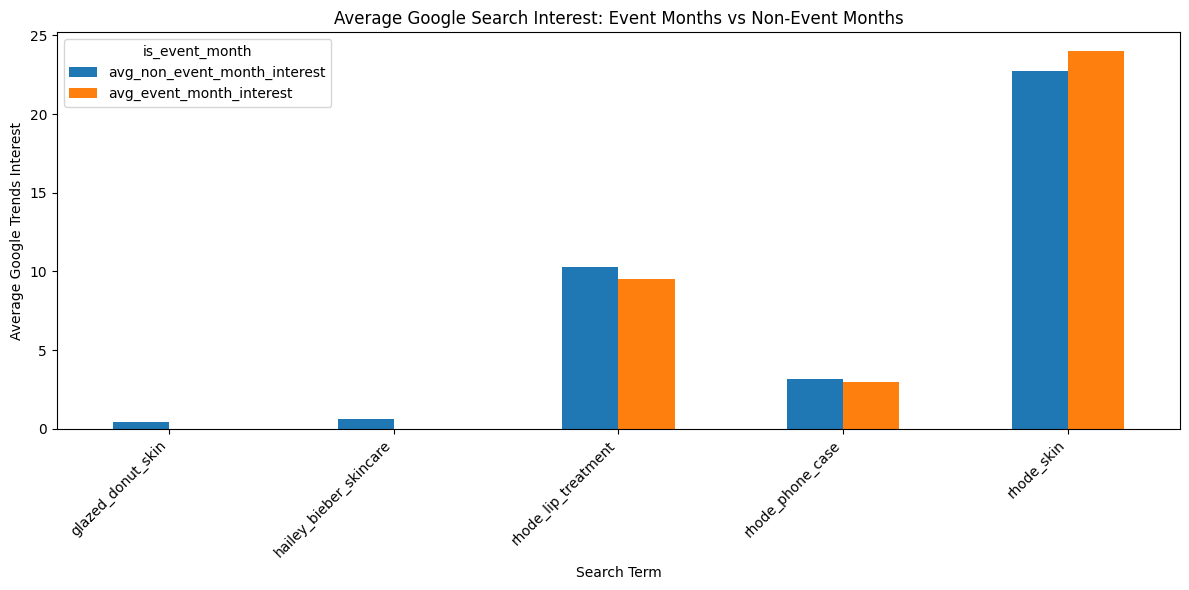

In [27]:
event_comparison_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Google Search Interest: Event Months vs Non-Event Months")
plt.xlabel("Search Term")
plt.ylabel("Average Google Trends Interest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

This chart shows that event months do not automatically produce higher search interest for every Rhode-related term. The strongest increase appears for “rhode_skin,” suggesting that major brand-level events are more likely to boost general searches for Rhode. However, product-specific terms like “rhode_lip_treatment” and “rhode_phone_case” do not show the same clear increase, which may mean that search interest happens before or after official launch months as products spread through social media. Overall, the data suggests that Rhode’s visibility is partly connected to events, but also shaped by broader celebrity and viral beauty culture.

Next, we're going to establish the correlation between events and search interest.

In [28]:
correlation_table = final_dataset.groupby("search_term").apply(
    lambda x: x["is_event_month"].corr(x["google_trends_interest"])
).reset_index()

correlation_table.columns = [
    "search_term",
    "correlation_between_event_month_and_search_interest"
]

correlation_table = correlation_table.sort_values(
    "correlation_between_event_month_and_search_interest",
    ascending=False
)

correlation_table

,search_term,correlation_between_event_month_and_search_interest
4,rhode_skin,0.017737
3,rhode_phone_case,-0.005137
2,rhode_lip_treatment,-0.018320
0,glazed_donut_skin,-0.086095
1,hailey_bieber_skincare,-0.186284


In [29]:
correlation_table.to_csv("rhode_event_search_correlation.csv", index=False)

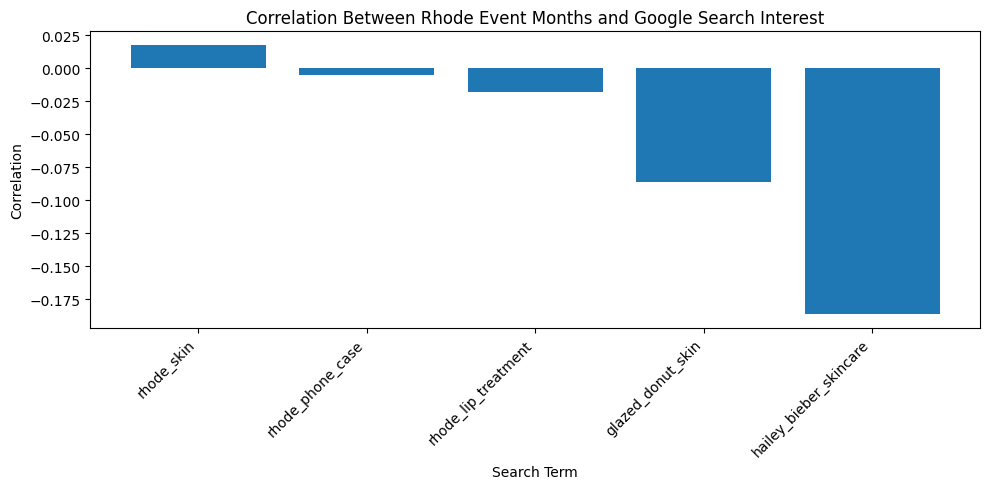

In [30]:
plt.figure(figsize=(10, 5))

plt.bar(
    correlation_table["search_term"],
    correlation_table["correlation_between_event_month_and_search_interest"]
)

plt.title("Correlation Between Rhode Event Months and Google Search Interest")
plt.xlabel("Search Term")
plt.ylabel("Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The correlation chart suggests that the relationship between Rhode event months and Google search interest is weak overall. Most search terms have correlations close to zero, meaning that simply coding a month as an “event month” does not strongly predict higher search interest. The only slightly positive relationship appears for “rhode_skin,” which makes sense because this is the broadest brand-level term and is most likely to respond to major Rhode events like the brand launch, retail expansion, or acquisition news.

However, several terms show slightly negative correlations, including “glazed_donut_skin” and “Hailey Bieber skincare.” This does not necessarily mean that Rhode events reduced search interest. Rather, it suggests that these broader beauty and celebrity-related terms may not align neatly with official brand events. Their search patterns may be shaped by other factors, such as TikTok trends, celebrity discourse, seasonal beauty interest, or media coverage that falls outside the event dates coded in this dataset.

Overall, this chart complicates the original hypothesis. While the timeline graphs may show individual spikes around specific product moments, the correlation results suggest that Rhode’s search attention is not explained by event timing alone. Public interest appears to be more uneven and culturally driven, especially for terms connected to Hailey Bieber’s broader beauty image rather than specific Rhode product launches.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

trends = pd.read_csv("rhodebeauty.csv", skiprows=1, header=None)

trends.head()

,0,1,2,3,4,5
0,2021-05-01,2,0,1,0,0
1,2021-06-01,2,0,1,0,0
2,2021-07-01,2,0,0,0,0
3,2021-08-01,2,0,1,0,0
4,2021-09-01,1,0,0,0,0


In [6]:
trends.columns = [
    "date",
    "rhode_skin",
    "rhode_lip_treatment",
    "rhode_phone_case",
    "glazed_donut_skin",
    "hailey_bieber_skincare"
]

trends["date"] = pd.to_datetime(trends["date"])

trends.head()

,date,rhode_skin,rhode_lip_treatment,rhode_phone_case,glazed_donut_skin,hailey_bieber_skincare
0,2021-05-01,2,0,1,0,0
1,2021-06-01,2,0,1,0,0
2,2021-07-01,2,0,0,0,0
3,2021-08-01,2,0,1,0,0
4,2021-09-01,1,0,0,0,0


In [7]:
trends_long = trends.melt(
    id_vars="date",
    var_name="search_term",
    value_name="google_trends_interest"
)

trends_long.head()

,date,search_term,google_trends_interest
0,2021-05-01,rhode_skin,2
1,2021-06-01,rhode_skin,2
2,2021-07-01,rhode_skin,2
3,2021-08-01,rhode_skin,2
4,2021-09-01,rhode_skin,1


In [13]:
trends_long["search_term"].value_counts()
trends_long.sort_values(["date", "search_term"]).head(20)

,date,search_term,google_trends_interest,month
183,2021-05-01,glazed_donut_skin,0,2021-05-01
244,2021-05-01,hailey_bieber_skincare,0,2021-05-01
61,2021-05-01,rhode_lip_treatment,0,2021-05-01
122,2021-05-01,rhode_phone_case,1,2021-05-01
0,2021-05-01,rhode_skin,2,2021-05-01
184,2021-06-01,glazed_donut_skin,0,2021-06-01
245,2021-06-01,hailey_bieber_skincare,0,2021-06-01
62,2021-06-01,rhode_lip_treatment,0,2021-06-01
123,2021-06-01,rhode_phone_case,1,2021-06-01
1,2021-06-01,rhode_skin,2,2021-06-01


In [14]:
trends_long["month"] = trends_long["date"].dt.to_period("M").dt.start_time

trends_long.head()

,date,search_term,google_trends_interest,month
0,2021-05-01,rhode_skin,2,2021-05-01
1,2021-06-01,rhode_skin,2,2021-06-01
2,2021-07-01,rhode_skin,2,2021-07-01
3,2021-08-01,rhode_skin,2,2021-08-01
4,2021-09-01,rhode_skin,1,2021-09-01


In [15]:
events = pd.DataFrame({
    "date": pd.to_datetime([
        "2022-01-27",
        "2022-06-15",
        "2022-06-15",
        "2023-03-22",
        "2023-08-28",
        "2023-09-28",
        "2024-01-25",
        "2024-02-27",
        "2024-06-20",
        "2024-10-28",
        "2025-01-30",
        "2025-05-28",
        "2025-09-04"
    ]),
    "event_name": [
        "Glazed donut skin identified as major Hailey Bieber beauty trend",
        "Rhode officially launches",
        "Peptide Lip Treatment included in first Rhode drop",
        "Rhode reports major waitlist and expansion momentum",
        "Strawberry Glaze Peptide Lip Treatment launches with Krispy Kreme",
        "Rhode Peptide Lip Tint launches",
        "Pineapple Refresh Cleanser becomes available",
        "Rhode Lip Case launches",
        "Rhode Pocket Blush launches",
        "Rhode Barrier Butter launches",
        "Peptide Lip Shape launches",
        "e.l.f. Beauty announces Rhode acquisition",
        "Rhode launches at Sephora U.S. and Canada"
    ],
    "event_type": [
        "viral_beauty_trend",
        "brand_launch",
        "product_launch",
        "business_growth",
        "product_collab",
        "product_launch",
        "skincare_product_launch",
        "viral_product_launch",
        "color_cosmetics_launch",
        "skincare_product_launch",
        "lip_product_launch",
        "business_event",
        "retail_expansion"
    ],
    "related_search_term": [
        "glazed_donut_skin",
        "rhode_skin",
        "rhode_lip_treatment",
        "rhode_skin",
        "rhode_lip_treatment",
        "rhode_lip_treatment",
        "rhode_skin",
        "rhode_phone_case",
        "hailey_bieber_skincare",
        "rhode_skin",
        "rhode_lip_treatment",
        "rhode_skin",
        "hailey_bieber_skincare"
    ]
})

events.head()

,date,event_name,event_type,related_search_term
0,2022-01-27,Glazed donut skin identified as major Hailey B...,viral_beauty_trend,glazed_donut_skin
1,2022-06-15,Rhode officially launches,brand_launch,rhode_skin
2,2022-06-15,Peptide Lip Treatment included in first Rhode ...,product_launch,rhode_lip_treatment
3,2023-03-22,Rhode reports major waitlist and expansion mom...,business_growth,rhode_skin
4,2023-08-28,Strawberry Glaze Peptide Lip Treatment launche...,product_collab,rhode_lip_treatment


In [16]:
events["month"] = events["date"].dt.to_period("M").dt.start_time

events.head()

,date,event_name,event_type,related_search_term,month
0,2022-01-27,Glazed donut skin identified as major Hailey B...,viral_beauty_trend,glazed_donut_skin,2022-01-01
1,2022-06-15,Rhode officially launches,brand_launch,rhode_skin,2022-06-01
2,2022-06-15,Peptide Lip Treatment included in first Rhode ...,product_launch,rhode_lip_treatment,2022-06-01
3,2023-03-22,Rhode reports major waitlist and expansion mom...,business_growth,rhode_skin,2023-03-01
4,2023-08-28,Strawberry Glaze Peptide Lip Treatment launche...,product_collab,rhode_lip_treatment,2023-08-01


In [40]:
merged["event_name"] = merged["event_name"].fillna("none")
merged["event_type"] = merged["event_type"].fillna("none")
merged["related_search_term"] = merged["related_search_term"].fillna("none")

merged["is_event_month"] = merged["event_type"].apply(
    lambda x: 0 if x == "none" else 1
)

In [21]:
final_dataset = merged[[
    "month",
    "search_term",
    "google_trends_interest",
    "event_name",
    "event_type",
    "is_event_month"
]]

final_dataset.head()

,month,search_term,google_trends_interest,event_name,event_type,is_event_month
0,2021-05-01,rhode_skin,2,none,none,0
1,2021-06-01,rhode_skin,2,none,none,0
2,2021-07-01,rhode_skin,2,none,none,0
3,2021-08-01,rhode_skin,2,none,none,0
4,2021-09-01,rhode_skin,1,none,none,0


In [22]:
final_dataset[final_dataset["is_event_month"] == 1]

,month,search_term,google_trends_interest,event_name,event_type,is_event_month
13,2022-06-01,rhode_skin,35,Rhode officially launches,brand_launch,1
22,2023-03-01,rhode_skin,13,Rhode reports major waitlist and expansion mom...,business_growth,1
32,2024-01-01,rhode_skin,22,Pineapple Refresh Cleanser becomes available,skincare_product_launch,1
41,2024-10-01,rhode_skin,21,Rhode Barrier Butter launches,skincare_product_launch,1
48,2025-05-01,rhode_skin,29,e.l.f. Beauty announces Rhode acquisition,business_event,1
74,2022-06-01,rhode_lip_treatment,3,Peptide Lip Treatment included in first Rhode ...,product_launch,1
88,2023-08-01,rhode_lip_treatment,9,Strawberry Glaze Peptide Lip Treatment launche...,product_collab,1
89,2023-09-01,rhode_lip_treatment,14,Rhode Peptide Lip Tint launches,product_launch,1
105,2025-01-01,rhode_lip_treatment,12,Peptide Lip Shape launches,lip_product_launch,1
155,2024-02-01,rhode_phone_case,3,Rhode Lip Case launches,viral_product_launch,1


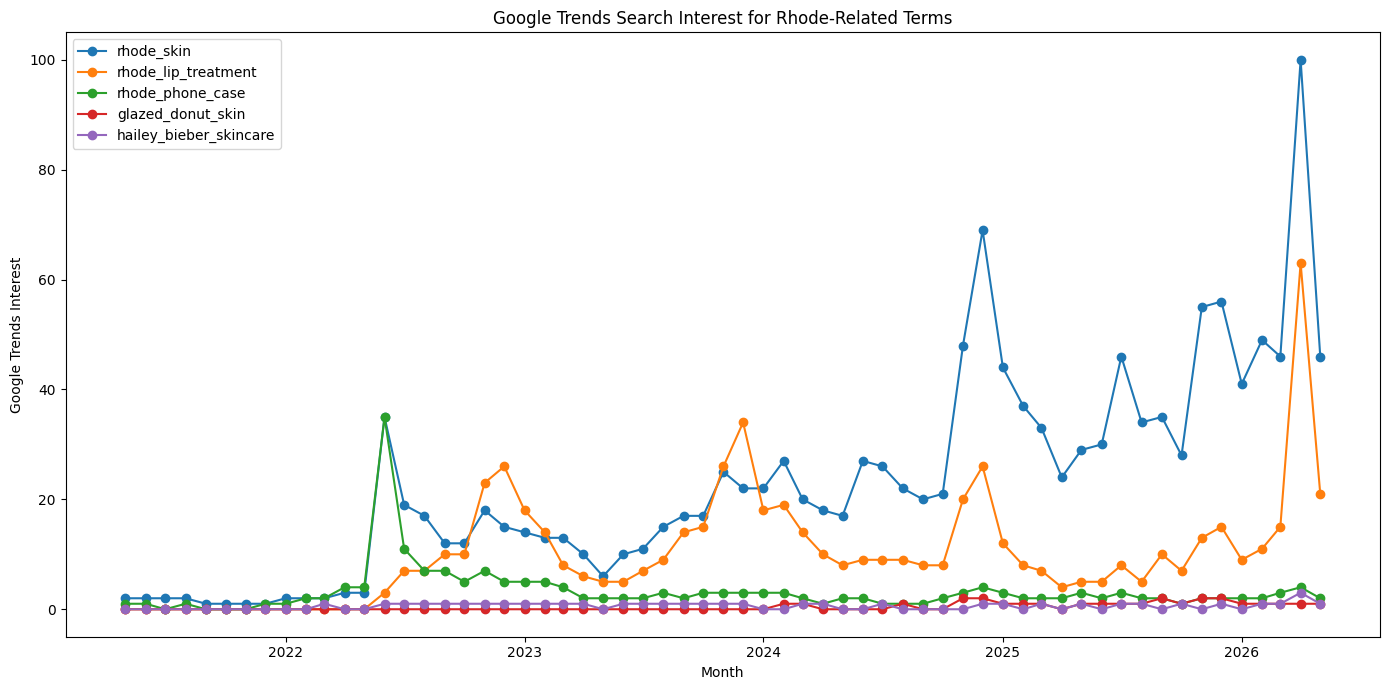

In [26]:
plt.figure(figsize=(14, 7))

for term in final_dataset["search_term"].unique():
    subset = final_dataset[final_dataset["search_term"] == term]
    plt.plot(
        subset["month"],
        subset["google_trends_interest"],
        marker="o",
        label=term
    )

plt.title("Google Trends Search Interest for Rhode-Related Terms")
plt.xlabel("Month")
plt.ylabel("Google Trends Interest")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
event_comparison = final_dataset.groupby(
    ["search_term", "is_event_month"]
)["google_trends_interest"].mean().reset_index()

event_comparison

,search_term,is_event_month,google_trends_interest
0,glazed_donut_skin,0,0.433333
1,glazed_donut_skin,1,0.000000
2,hailey_bieber_skincare,0,0.610169
3,hailey_bieber_skincare,1,0.000000
4,rhode_lip_treatment,0,10.263158
5,rhode_lip_treatment,1,9.500000
6,rhode_phone_case,0,3.183333
7,rhode_phone_case,1,3.000000
8,rhode_skin,0,22.767857
9,rhode_skin,1,24.000000


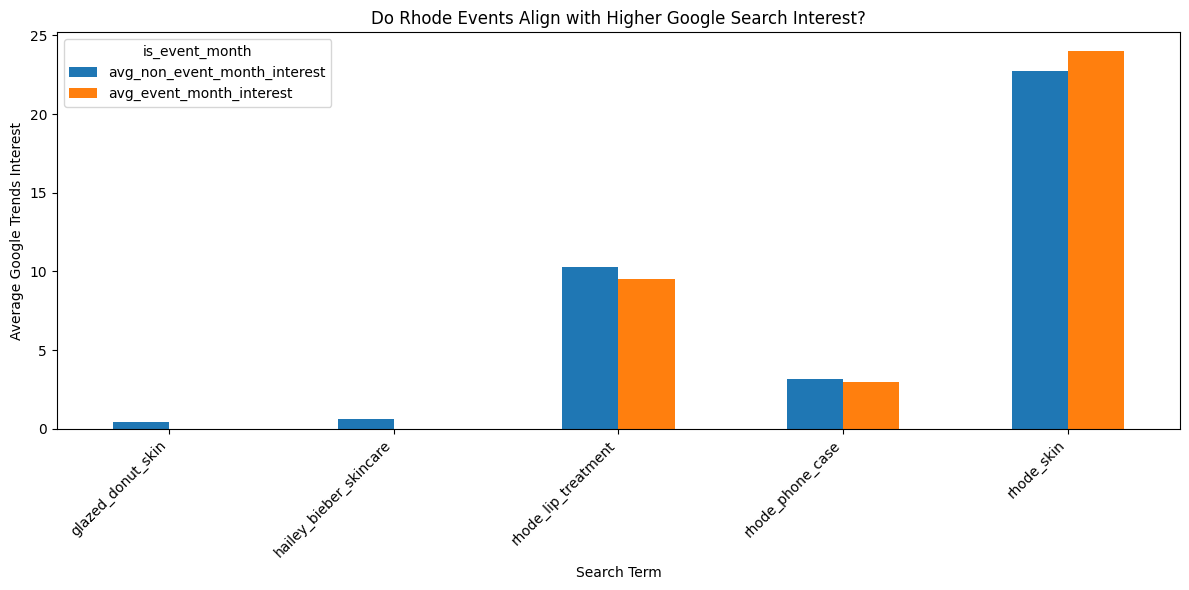

In [30]:
event_comparison_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Do Rhode Events Align with Higher Google Search Interest?")
plt.xlabel("Search Term")
plt.ylabel("Average Google Trends Interest")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()